In [1]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Machine A October**

In [3]:
from google.colab import files
import pandas as pd

# Open file picker
uploaded = files.upload()

# Get the uploaded file name
filename = list(uploaded.keys())[0]

# Read the CSV
df = pd.read_csv(filename, encoding='latin1')
df.head()

Saving MACHINE_A_OCTOBER_FINAL.csv to MACHINE_A_OCTOBER_FINAL.csv


,Group Name,Machine,Transaction Date,Transaction No,Slot No,Product Code,Menu,Service,Status,Delivery,Categories,Price
0,Master,Machine A,31-10-25 20:34,3216039,31,UMMIS3,Chicken & Yuzu Poke Bowl,Cash,Successful,Delivery,Non vegetarian,Standard
1,Master,Machine A,31-10-25 20:16,3215947,21,UMMIS17,Chicken Brown & Wild Rice Salad,Cash,Successful,Delivery,Non vegetarian,Standard
2,Master,Machine A,31-10-25 19:42,3215444,17,UMMIF1,Banana Berry Acai Bowl,Cash,Successful,Delivery,Gluten-free,Affordable
3,Master,Machine A,31-10-25 19:40,3215387,11,UMMIV10,Fajita Chicken Wrap,Cash,Successful,Delivery,Non vegetarian,Standard
4,Master,Machine A,31-10-25 19:40,3215231,61,UMMIS7,Pumpkin & Beetroot Salad with Orange Vinaigrette,Cash,Successful,Delivery,Vegetarian,Standard


In [4]:
# Clean Column Names
import pandas as pd

df.columns = [
    "GroupName",
    "Machine",
    "TransactionDate",
    "TransactionNo",
    "SlotNo",
    "ProductCode",
    "ProductName",
    "Service",
    "Status",
    "Delivery",
    "Categories",
    "Price"
]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price
0,Master,Machine A,31-10-25 20:34,3216039,31,UMMIS3,Chicken & Yuzu Poke Bowl,Cash,Successful,Delivery,Non vegetarian,Standard
1,Master,Machine A,31-10-25 20:16,3215947,21,UMMIS17,Chicken Brown & Wild Rice Salad,Cash,Successful,Delivery,Non vegetarian,Standard
2,Master,Machine A,31-10-25 19:42,3215444,17,UMMIF1,Banana Berry Acai Bowl,Cash,Successful,Delivery,Gluten-free,Affordable
3,Master,Machine A,31-10-25 19:40,3215387,11,UMMIV10,Fajita Chicken Wrap,Cash,Successful,Delivery,Non vegetarian,Standard
4,Master,Machine A,31-10-25 19:40,3215231,61,UMMIS7,Pumpkin & Beetroot Salad with Orange Vinaigrette,Cash,Successful,Delivery,Vegetarian,Standard


In [5]:
# Feature Engineering
import pandas as pd

# Parse the date correctly (DD-MM-YY HH:MM)
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], format="%d-%m-%y %H:%M")

# Extract useful time features
df["Hour"] = df["TransactionDate"].dt.hour
df["Day"] = df["TransactionDate"].dt.day
df["Weekday"] = df["TransactionDate"].dt.weekday

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine A,2025-10-31 20:34:00,3216039,31,UMMIS3,Chicken & Yuzu Poke Bowl,Cash,Successful,Delivery,Non vegetarian,Standard,20,31,4
1,Master,Machine A,2025-10-31 20:16:00,3215947,21,UMMIS17,Chicken Brown & Wild Rice Salad,Cash,Successful,Delivery,Non vegetarian,Standard,20,31,4
2,Master,Machine A,2025-10-31 19:42:00,3215444,17,UMMIF1,Banana Berry Acai Bowl,Cash,Successful,Delivery,Gluten-free,Affordable,19,31,4
3,Master,Machine A,2025-10-31 19:40:00,3215387,11,UMMIV10,Fajita Chicken Wrap,Cash,Successful,Delivery,Non vegetarian,Standard,19,31,4
4,Master,Machine A,2025-10-31 19:40:00,3215231,61,UMMIS7,Pumpkin & Beetroot Salad with Orange Vinaigrette,Cash,Successful,Delivery,Vegetarian,Standard,19,31,4


In [7]:
# Hourly Sales & Peak Label
hourly_sales = df.groupby(["Machine", "TransactionDate", "Weekday", "Hour"]).size().reset_index(name="Count")

# Peak threshold = top 33%
peak_threshold = hourly_sales["Count"].quantile(0.67)
hourly_sales["Is_Peak"] = (hourly_sales["Count"] > peak_threshold).astype(int)

In [8]:
# Defining Features
X = hourly_sales[["Machine", "Weekday", "Hour"]]
y = hourly_sales["Is_Peak"]

le_machine = LabelEncoder()
le_weekday = LabelEncoder()

X["Machine"] = le_machine.fit_transform(X["Machine"])
X["Weekday"] = le_weekday.fit_transform(X["Weekday"])

/tmp/ipykernel_466/3375398488.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Machine"] = le_machine.fit_transform(X["Machine"])
/tmp/ipykernel_466/3375398488.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Weekday"] = le_weekday.fit_transform(X["Weekday"])


In [9]:
# Training / Testing Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [10]:
# Random Forest Model

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report (Peak vs Non-Peak):")
print(classification_report(y_test, y_pred))

Classification Report (Peak vs Non-Peak):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       119
           1       0.00      0.00      0.00         1

    accuracy                           0.99       120
   macro avg       0.50      0.50      0.50       120
weighted avg       0.98      0.99      0.99       120



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/tmp/ipykernel_466/2388989319.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


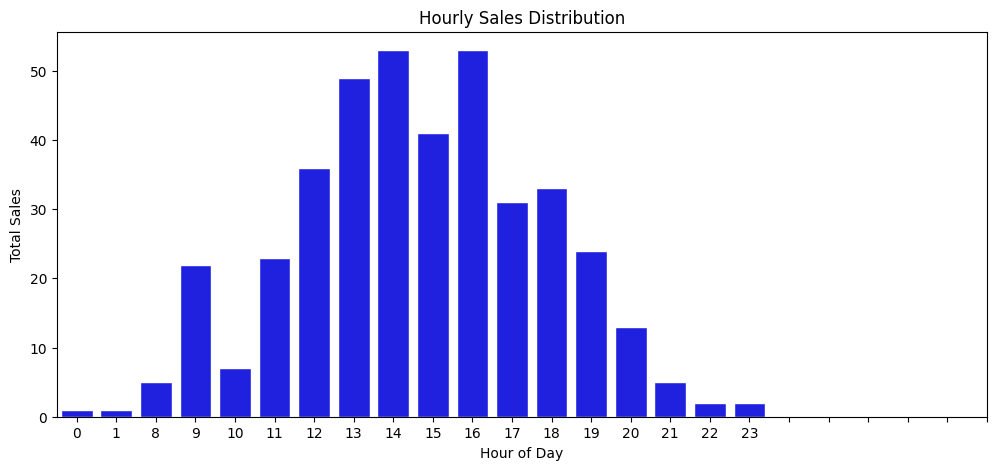

In [13]:
# Hourly Sales Distribution

plt.figure(figsize=(12,5))
sns.barplot(
    data=hourly_sales,
    x="Hour",
    y="Count",
    estimator=sum,
    ci=None,
    color="blue",
    edgecolor="white"
)
plt.title("Hourly Sales Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales")
plt.xticks(range(0,24))
plt.show()

/tmp/ipykernel_466/3185753054.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


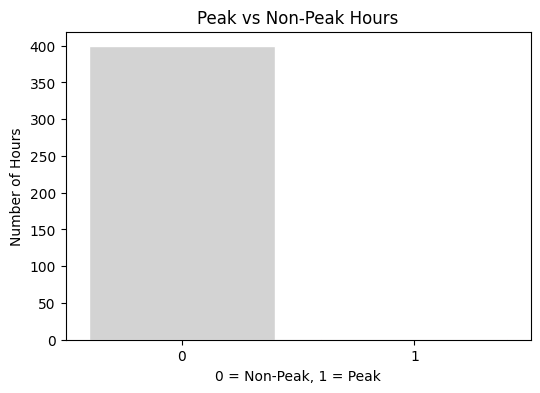

In [16]:
# Peak vs Non - Peak Count

plt.figure(figsize=(6,4))
sns.countplot(
    data=hourly_sales,
    x="Is_Peak",
    palette=["lightgray", "crimson"],
    edgecolor="white"
)
plt.title("Peak vs Non-Peak Hours")
plt.xlabel("0 = Non-Peak, 1 = Peak")
plt.ylabel("Number of Hours")
plt.show()

**Machine B October**

In [33]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
from google.colab import files
import pandas as pd

# Open file picker
uploaded = files.upload()

# Get the uploaded file name
filename = list(uploaded.keys())[0]

# Read the CSV
df = pd.read_csv(filename, encoding='latin1')
df.head()

Saving MACHINE_B_OCTOBER_FINAL.csv to MACHINE_B_OCTOBER_FINAL.csv


,ï»¿Group Name,Machine,Transaction Date,Transaction No,Slot No,Product Code,Menu,Service,Status,Delivery,Category,Price
0,Master,Machine B,2025-10-31 07:51:50,3216354,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable
1,Master,Machine B,2025-10-31 05:31:24,3214755,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable
2,Master,Machine B,2025-10-31 16:14:09,3211802,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable
3,Master,Machine B,2025-10-31 15:33:35,3210031,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable
4,Master,Machine B,2025-10-31 01:10:43,3208401,31,UMMIR14,Herb Mushroom Chicken With Farfalle Pesto,Cash,Successful,Delivery,Non vegetarian,Premium


In [36]:
# Clean Column Names
import pandas as pd

df.columns = [
    "GroupName",
    "Machine",
    "TransactionDate",
    "TransactionNo",
    "SlotNo",
    "ProductCode",
    "ProductName",
    "Service",
    "Status",
    "Delivery",
    "Categories",
    "Price"
]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price
0,Master,Machine B,2025-10-31 07:51:50,3216354,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable
1,Master,Machine B,2025-10-31 05:31:24,3214755,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable
2,Master,Machine B,2025-10-31 16:14:09,3211802,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable
3,Master,Machine B,2025-10-31 15:33:35,3210031,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable
4,Master,Machine B,2025-10-31 01:10:43,3208401,31,UMMIR14,Herb Mushroom Chicken With Farfalle Pesto,Cash,Successful,Delivery,Non vegetarian,Premium


In [39]:
# Feature Engineering
import pandas as pd

# Parse the date correctly (DD-MM-YY HH:MM)
df["TransactionDate"] = pd.to_datetime(
    df["TransactionDate"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

# Extract useful time features
df["Hour"] = df["TransactionDate"].dt.hour
df["Day"] = df["TransactionDate"].dt.day
df["Weekday"] = df["TransactionDate"].dt.weekday

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine B,2025-10-31 07:51:50,3216354,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable,7,31,4
1,Master,Machine B,2025-10-31 05:31:24,3214755,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable,5,31,4
2,Master,Machine B,2025-10-31 16:14:09,3211802,2,UMMIJ5,Watermelon Juice Fresh,Cash,Successful,Delivery,Beverage,Affordable,16,31,4
3,Master,Machine B,2025-10-31 15:33:35,3210031,3,UMMIM1,Mixed Berry Smoothie,Cash,Successful,Delivery,Beverage,Affordable,15,31,4
4,Master,Machine B,2025-10-31 01:10:43,3208401,31,UMMIR14,Herb Mushroom Chicken With Farfalle Pesto,Cash,Successful,Delivery,Non vegetarian,Premium,1,31,4


In [40]:
# Hourly Sales & Peak Label
hourly_sales = df.groupby(["Machine", "TransactionDate", "Weekday", "Hour"]).size().reset_index(name="Count")

# Peak threshold = top 33%
peak_threshold = hourly_sales["Count"].quantile(0.67)
hourly_sales["Is_Peak"] = (hourly_sales["Count"] > peak_threshold).astype(int)

In [41]:
# Defining Features
X = hourly_sales[["Machine", "Weekday", "Hour"]]
y = hourly_sales["Is_Peak"]

le_machine = LabelEncoder()
le_weekday = LabelEncoder()

X["Machine"] = le_machine.fit_transform(X["Machine"])
X["Weekday"] = le_weekday.fit_transform(X["Weekday"])

/tmp/ipykernel_466/3375398488.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Machine"] = le_machine.fit_transform(X["Machine"])
/tmp/ipykernel_466/3375398488.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Weekday"] = le_weekday.fit_transform(X["Weekday"])


In [42]:
# Training / Testing Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [43]:
# Random Forest Model

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report (Peak vs Non-Peak):")
print(classification_report(y_test, y_pred))

Classification Report (Peak vs Non-Peak):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       120

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



/tmp/ipykernel_466/1778841712.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


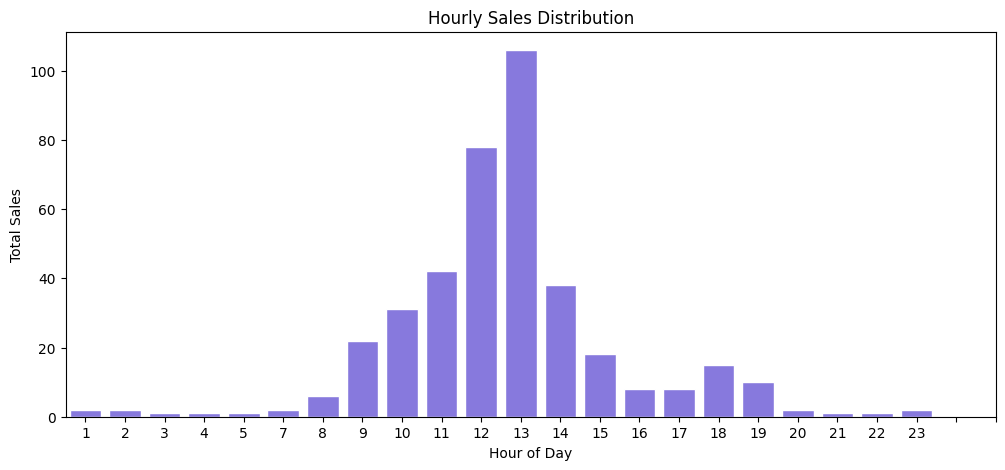

In [56]:
# Hourly Sales Distribution

plt.figure(figsize=(12,5))
sns.barplot(
    data=hourly_sales,
    x="Hour",
    y="Count",
    estimator=sum,
    ci=None,
    color="mediumslateblue",
    edgecolor="white"
)
plt.title("Hourly Sales Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales")
plt.xticks(range(0,24))
plt.show()

/tmp/ipykernel_466/4125447732.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_466/4125447732.py:4: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.countplot(


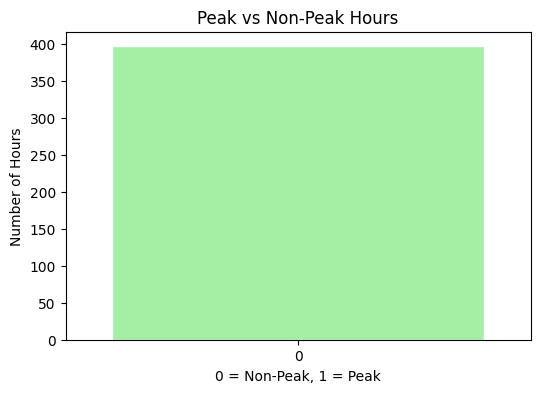

In [57]:
# Peak vs Non - Peak Count

plt.figure(figsize=(6,4))
sns.countplot(
    data=hourly_sales,
    x="Is_Peak",
    palette=["palegreen", "deepskyblue"],
    edgecolor="white"
)
plt.title("Peak vs Non-Peak Hours")
plt.xlabel("0 = Non-Peak, 1 = Peak")
plt.ylabel("Number of Hours")
plt.show()

**Machine A November**

In [18]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
from google.colab import files
import pandas as pd

# Open file picker
uploaded = files.upload()

# Get the uploaded file name
filename = list(uploaded.keys())[0]

# Read the CSV
df = pd.read_csv(filename, encoding='latin1')
df.head()

Saving MACHINE_A_NOVEMBER_FINAL.csv to MACHINE_A_NOVEMBER_FINAL.csv


,Group Name,Machine,Transaction Date,Transaction No,Slot No,Product Code,Product Name,Service,Status,Delivery,Category,Price
0,Master,Machine A,28-11-25 17:04,3995547,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
1,Master,Machine A,28-11-25 14:10,3992640,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
2,Master,Machine A,28-11-25 13:32,3991769,37,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium
3,Master,Machine A,28-11-25 13:17,3990658,17,UMMIR13,Spicy Chicken with Pearl CousCous,Cash,Successful,Delivery,Non vegetarian,Standard
4,Master,Machine A,28-11-25 12:36,3988280,51,UMMIS5,Mixed Beans & CousCous Salad,Cash,Successful,Delivery,Vegetarian,Standard


In [21]:
# Clean Column Names
import pandas as pd

df.columns = [
    "GroupName",
    "Machine",
    "TransactionDate",
    "TransactionNo",
    "SlotNo",
    "ProductCode",
    "ProductName",
    "Service",
    "Status",
    "Delivery",
    "Categories",
    "Price"
]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price
0,Master,Machine A,28-11-25 17:04,3995547,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
1,Master,Machine A,28-11-25 14:10,3992640,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
2,Master,Machine A,28-11-25 13:32,3991769,37,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium
3,Master,Machine A,28-11-25 13:17,3990658,17,UMMIR13,Spicy Chicken with Pearl CousCous,Cash,Successful,Delivery,Non vegetarian,Standard
4,Master,Machine A,28-11-25 12:36,3988280,51,UMMIS5,Mixed Beans & CousCous Salad,Cash,Successful,Delivery,Vegetarian,Standard


In [22]:
# Feature Engineering
import pandas as pd

# Parse the date correctly (DD-MM-YY HH:MM)
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], format="%d-%m-%y %H:%M")

# Extract useful time features
df["Hour"] = df["TransactionDate"].dt.hour
df["Day"] = df["TransactionDate"].dt.day
df["Weekday"] = df["TransactionDate"].dt.weekday

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine A,2025-11-28 17:04:00,3995547,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,17,28,4
1,Master,Machine A,2025-11-28 14:10:00,3992640,31,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,14,28,4
2,Master,Machine A,2025-11-28 13:32:00,3991769,37,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium,13,28,4
3,Master,Machine A,2025-11-28 13:17:00,3990658,17,UMMIR13,Spicy Chicken with Pearl CousCous,Cash,Successful,Delivery,Non vegetarian,Standard,13,28,4
4,Master,Machine A,2025-11-28 12:36:00,3988280,51,UMMIS5,Mixed Beans & CousCous Salad,Cash,Successful,Delivery,Vegetarian,Standard,12,28,4


In [23]:
# Hourly Sales & Peak Label
hourly_sales = df.groupby(["Machine", "TransactionDate", "Weekday", "Hour"]).size().reset_index(name="Count")

# Peak threshold = top 33%
peak_threshold = hourly_sales["Count"].quantile(0.67)
hourly_sales["Is_Peak"] = (hourly_sales["Count"] > peak_threshold).astype(int)

In [24]:
# Defining Features
X = hourly_sales[["Machine", "Weekday", "Hour"]]
y = hourly_sales["Is_Peak"]

le_machine = LabelEncoder()
le_weekday = LabelEncoder()

X["Machine"] = le_machine.fit_transform(X["Machine"])
X["Weekday"] = le_weekday.fit_transform(X["Weekday"])

/tmp/ipykernel_466/3375398488.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Machine"] = le_machine.fit_transform(X["Machine"])
/tmp/ipykernel_466/3375398488.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Weekday"] = le_weekday.fit_transform(X["Weekday"])


In [25]:
# Training / Testing Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [26]:
# Random Forest Model

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report (Peak vs Non-Peak):")
print(classification_report(y_test, y_pred))

Classification Report (Peak vs Non-Peak):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       138
           1       0.00      0.00      0.00         1

    accuracy                           0.99       139
   macro avg       0.50      0.50      0.50       139
weighted avg       0.99      0.99      0.99       139



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/tmp/ipykernel_466/563432534.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


([<matplotlib.axis.XTick at 0x7b737f159fa0>,
 [Text(0, 0, '1'),
  Text(1, 0, '7'),
  Text(2, 0, '8'),
  Text(3, 0, '9'),
  Text(4, 0, '10'),
  Text(5, 0, '11'),
  Text(6, 0, '12'),
  Text(7, 0, '13'),
  Text(8, 0, '14'),
  Text(9, 0, '15'),
  Text(10, 0, '16'),
  Text(11, 0, '17'),
  Text(12, 0, '18'),
  Text(13, 0, '19'),
  Text(14, 0, '20'),
  Text(15, 0, '21'),
  Text(16, 0, '22'),
  Text(17, 0, '23'),
  Text(18, 0, ''),
  Text(19, 0, ''),
  Text(20, 0, ''),
  Text(21, 0, ''),
  Text(22, 0, ''),
  Text(23, 0, '')])

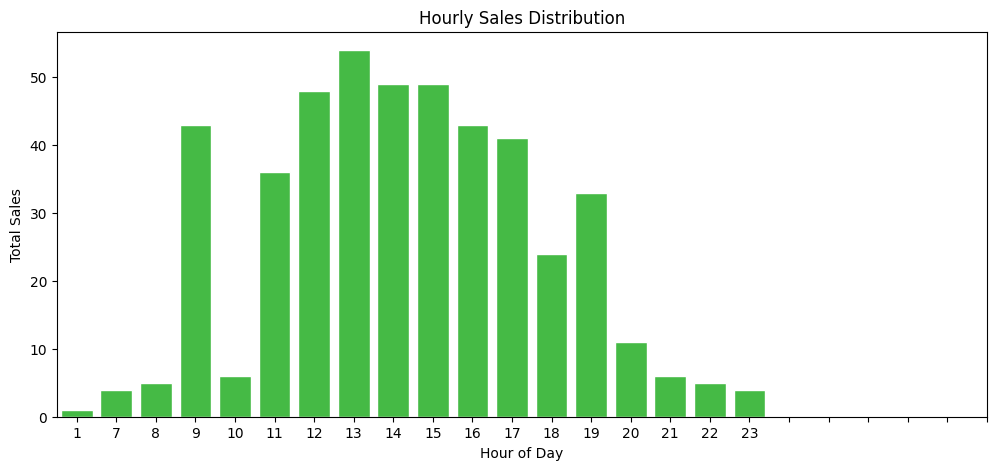

In [31]:
# Hourly Sales Distribution

plt.figure(figsize=(12,5))
sns.barplot(
    data=hourly_sales,
    x="Hour",
    y="Count",
    estimator=sum,
    ci=None,
    color="limegreen",
    edgecolor="white"
)
plt.title("Hourly Sales Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales")
plt.xticks(range(0,24))

/tmp/ipykernel_466/499004980.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


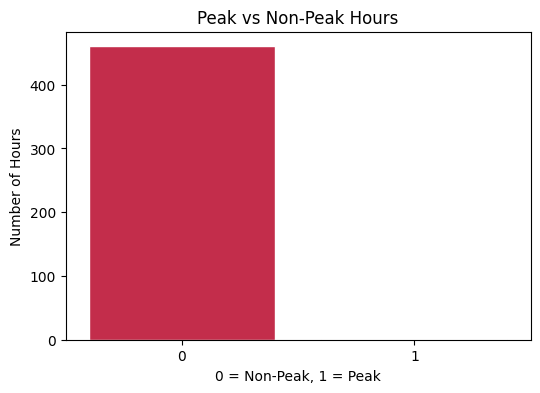

In [32]:
# Peak vs Non - Peak Count

plt.figure(figsize=(6,4))
sns.countplot(
    data=hourly_sales,
    x="Is_Peak",
    palette=["crimson", "orchid"],
    edgecolor="white"
)
plt.title("Peak vs Non-Peak Hours")
plt.xlabel("0 = Non-Peak, 1 = Peak")
plt.ylabel("Number of Hours")
plt.show()

**Machine B November**

In [58]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [60]:
from google.colab import files
import pandas as pd

# Open file picker
uploaded = files.upload()

# Get the uploaded file name
filename = list(uploaded.keys())[0]

# Read the CSV
df = pd.read_csv(filename, encoding='latin1')
df.head()

Saving MACHINE_B_NOVEMBER_FINAL.csv to MACHINE_B_NOVEMBER_FINAL.csv


,ï»¿Group Name,Machine,Transaction Date,Transaction No,Slot No,Product Code,Menu,Service,Status,Delivery,Category,Price
0,Master,Machine B,28-11-25 13:06,3990009,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
1,Master,Machine B,28-11-25 13:03,3989850,11,UMMIG1,Grilled Chicken Burrito Bowl,Cash,Successful,Delivery,Non vegetarian,Premium
2,Master,Machine B,28-11-25 09:25,3985694,27,UMMIR7,Sweet And Sour Prawn Teriyaki Noodles,Cash,Successful,Delivery,Non vegetarian,Premium
3,Master,Machine B,27-11-25 16:45,3983556,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
4,Master,Machine B,27-11-25 14:42,3980068,34,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium


In [61]:
# Clean Column Names
import pandas as pd

df.columns = [
    "GroupName",
    "Machine",
    "TransactionDate",
    "TransactionNo",
    "SlotNo",
    "ProductCode",
    "ProductName",
    "Service",
    "Status",
    "Delivery",
    "Categories",
    "Price"
]

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price
0,Master,Machine B,28-11-25 13:06,3990009,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
1,Master,Machine B,28-11-25 13:03,3989850,11,UMMIG1,Grilled Chicken Burrito Bowl,Cash,Successful,Delivery,Non vegetarian,Premium
2,Master,Machine B,28-11-25 09:25,3985694,27,UMMIR7,Sweet And Sour Prawn Teriyaki Noodles,Cash,Successful,Delivery,Non vegetarian,Premium
3,Master,Machine B,27-11-25 16:45,3983556,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium
4,Master,Machine B,27-11-25 14:42,3980068,34,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium


In [62]:
# Feature Engineering
import pandas as pd

# Parse the date correctly (DD-MM-YY HH:MM)
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], format="%d-%m-%y %H:%M")

# Extract useful time features
df["Hour"] = df["TransactionDate"].dt.hour
df["Day"] = df["TransactionDate"].dt.day
df["Weekday"] = df["TransactionDate"].dt.weekday

df.head()

,GroupName,Machine,TransactionDate,TransactionNo,SlotNo,ProductCode,ProductName,Service,Status,Delivery,Categories,Price,Hour,Day,Weekday
0,Master,Machine B,2025-11-28 13:06:00,3990009,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,13,28,4
1,Master,Machine B,2025-11-28 13:03:00,3989850,11,UMMIG1,Grilled Chicken Burrito Bowl,Cash,Successful,Delivery,Non vegetarian,Premium,13,28,4
2,Master,Machine B,2025-11-28 09:25:00,3985694,27,UMMIR7,Sweet And Sour Prawn Teriyaki Noodles,Cash,Successful,Delivery,Non vegetarian,Premium,9,28,4
3,Master,Machine B,2025-11-27 16:45:00,3983556,37,UMMIR4,Chicken Tandoori with Coriander Rice,Cash,Successful,Delivery,Non vegetarian,Premium,16,27,3
4,Master,Machine B,2025-11-27 14:42:00,3980068,34,UMMIR10,Creamy Chicken Pesto with Chunky Red Rice,Cash,Successful,Delivery,Non vegetarian,Premium,14,27,3


In [63]:
# Hourly Sales & Peak Label
hourly_sales = df.groupby(["Machine", "TransactionDate", "Weekday", "Hour"]).size().reset_index(name="Count")

# Peak threshold = top 33%
peak_threshold = hourly_sales["Count"].quantile(0.67)
hourly_sales["Is_Peak"] = (hourly_sales["Count"] > peak_threshold).astype(int)

In [64]:
# Defining Features
X = hourly_sales[["Machine", "Weekday", "Hour"]]
y = hourly_sales["Is_Peak"]

le_machine = LabelEncoder()
le_weekday = LabelEncoder()

X["Machine"] = le_machine.fit_transform(X["Machine"])
X["Weekday"] = le_weekday.fit_transform(X["Weekday"])

/tmp/ipykernel_466/3375398488.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Machine"] = le_machine.fit_transform(X["Machine"])
/tmp/ipykernel_466/3375398488.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Weekday"] = le_weekday.fit_transform(X["Weekday"])


In [65]:
# Training / Testing Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [66]:
# Random Forest Model

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Classification Report (Peak vs Non-Peak):")
print(classification_report(y_test, y_pred))

Classification Report (Peak vs Non-Peak):
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       104
           1       0.00      0.00      0.00         1

    accuracy                           0.99       105
   macro avg       0.50      0.50      0.50       105
weighted avg       0.98      0.99      0.99       105



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/tmp/ipykernel_466/1368896049.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


([<matplotlib.axis.XTick at 0x7b737ea926c0>,
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '5'),
  Text(4, 0, '6'),
  Text(5, 0, '8'),
  Text(6, 0, '9'),
  Text(7, 0, '10'),
  Text(8, 0, '11'),
  Text(9, 0, '12'),
  Text(10, 0, '13'),
  Text(11, 0, '14'),
  Text(12, 0, '15'),
  Text(13, 0, '16'),
  Text(14, 0, '17'),
  Text(15, 0, '18'),
  Text(16, 0, '19'),
  Text(17, 0, '20'),
  Text(18, 0, '21'),
  Text(19, 0, ''),
  Text(20, 0, ''),
  Text(21, 0, ''),
  Text(22, 0, ''),
  Text(23, 0, '')])

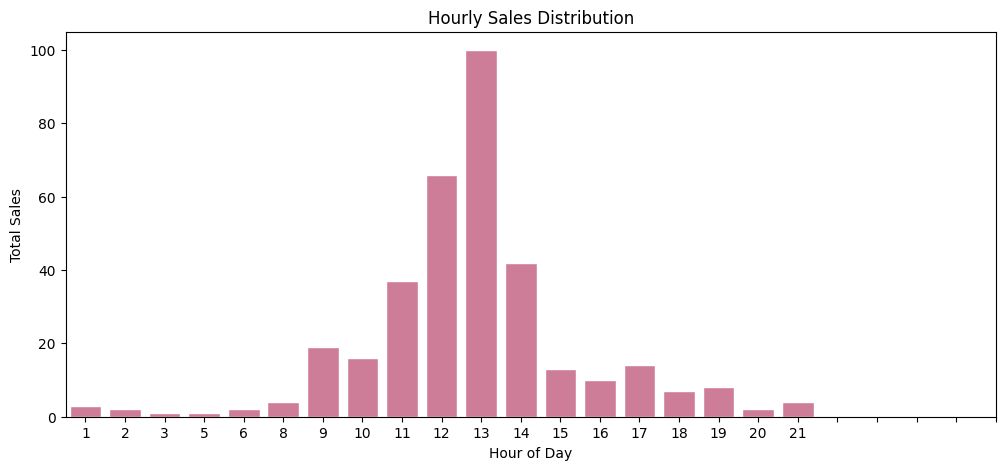

In [68]:
# Hourly Sales Distribution

plt.figure(figsize=(12,5))
sns.barplot(
    data=hourly_sales,
    x="Hour",
    y="Count",
    estimator=sum,
    ci=None,
    color="palevioletred",
    edgecolor="white"
)
plt.title("Hourly Sales Distribution")
plt.xlabel("Hour of Day")
plt.ylabel("Total Sales")
plt.xticks(range(0,24))

/tmp/ipykernel_466/1939495954.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


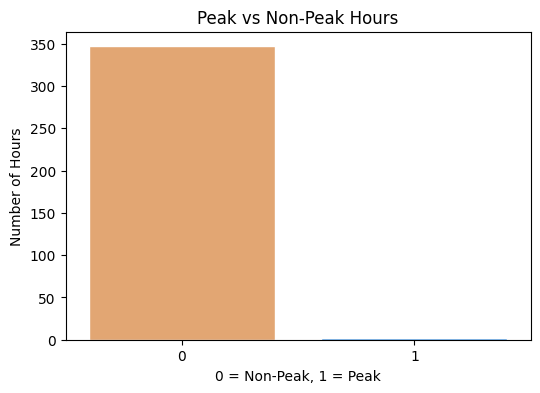

In [71]:
# Peak vs Non - Peak Count

plt.figure(figsize=(6,4))
sns.countplot(
    data=hourly_sales,
    x="Is_Peak",
    palette=["sandybrown", "dodgerblue"],
    edgecolor="white"
)
plt.title("Peak vs Non-Peak Hours")
plt.xlabel("0 = Non-Peak, 1 = Peak")
plt.ylabel("Number of Hours")
plt.show()